比较加入/不加入新feature时fasterrisk的表现

In [1]:
import os.path
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import os, time, json, math
from typing import List, Any, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from fasterrisk.fasterrisk import RiskScoreOptimizer, RiskScoreClassifier

In [2]:
# Set random seed for reproducibility
import random
np.random.seed(42)
random.seed(42)

## Config

In [3]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'growth_speed', 'growth_speed_pct']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 56, 57, 58, 59, 61, 64, 67],
    "sct_long_dia": [6, 10, 20, 30],
    "growth_speed": [-4, -3, -2, -1, 0, 1],
    "growth_speed_pct": [-2, -1, -0.5, -0.2, 0, 0.2, 0.5, 1.0, 2.0],
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex']

# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

## Helpers

In [4]:
def filter_age_le_70(df):
    return df[df['age'] <= 70]

def _norm_text(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    s = s.replace('_','-').replace('–','-').replace('—','-')
    return s

def normalize_and_encode(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Canonicalize gender to {'male','female'}
    - Canonicalize Nodule_Type to {'solid','ground-glass','part-solid'} using common aliases
    - Create binaries: sex, part_solid, ground_glass, solid
    - Coerce Upper_Lobe/Spiculation to ints if present
    - Drop rows with unmapped gender/Nodule_Type; warn on non-exclusive types
    """
    df = df.copy()

    # gender
    g = df['gender'].apply(_norm_text)
    df['gender'] = g.map({'male':'male','m':'male','female':'female','f':'female'})

    # nodule type
    t = df['Nodule_Type'].apply(_norm_text)
    mapping = {
        'solid':'solid', 'sld':'solid',

        'ground-glass':'ground-glass', 'ground glass':'ground-glass',
        'ggo':'ground-glass', 'non-solid':'ground-glass',
        'non solid':'ground-glass', 'nonsolid':'ground-glass',

        'part-solid':'part-solid', 'part solid':'part-solid',
        'semi-solid':'part-solid', 'semisolid':'part-solid', 'subsolid':'part-solid',
    }
    df['Nodule_Type'] = t.map(mapping)

    # drop unmapped
    bad = df['gender'].isna() | df['Nodule_Type'].isna()
    if bad.any():
        print(f"[filter] Dropping {int(bad.sum())} rows with unmapped gender or Nodule_Type")
        # Uncomment to inspect:
        # print(df.loc[bad, [ID_COL,'gender','Nodule_Type']].head(10))
        df = df.loc[~bad].copy()

    # binaries
    df['sex']          = df['gender'].map({'male':0, 'female':1}).astype(int)
    df['part_solid']   = (df['Nodule_Type'] == 'part-solid').astype(int)
    df['ground_glass'] = (df['Nodule_Type'] == 'ground-glass').astype(int)
    df['solid']        = (df['Nodule_Type'] == 'solid').astype(int)

    # passthrough ints
    for b in ['Upper_Lobe','Spiculation']:
        if b in df.columns:
            df[b] = pd.to_numeric(df[b], errors='ignore')
            df[b] = pd.to_numeric(df[b], errors='coerce').fillna(0).astype(int)

    # sanity: exactly one nodule type flag
    onehot_sum = df[['solid','ground_glass','part_solid']].sum(axis=1)
    if (onehot_sum != 1).any():
        print(f"[warn] {int((onehot_sum != 1).sum())} rows have non-exclusive nodule types; please inspect.")

    return df

def to_fastrisk_y(y_raw, pos_label=1) -> np.ndarray:
    """Return 1-D np.ndarray[float] with labels in {-1.0, +1.0}."""
    y_arr = np.asarray(y_raw).ravel()
    uniq = set(np.unique(y_arr))
    if uniq <= {0, 1}:
        return (2 * y_arr - 1).astype(float)
    return np.where(y_arr == pos_label, 1.0, -1.0).astype(float)

def make_ge_bins(df: pd.DataFrame, feature: str, cuts: list[float]) -> pd.DataFrame:
    """
    Build columns like 'age >= 73' or 'sct_long_dia >= 20' (ASCII >=)
    """
    out = pd.DataFrame(index=df.index)
    vals = pd.to_numeric(df[feature], errors='coerce')
    for c in cuts:
        col = f"{feature} >= {c:g}"
        out[col] = (vals >= float(c)).astype(int)
    return out

def build_binary_matrix(X_df: pd.DataFrame,
                        feature_cuts: dict[str, list[float]],
                        passthrough_binary: list[str]) -> pd.DataFrame:
    mats = []
    for feat, cuts in feature_cuts.items():
        if feat not in X_df.columns:
            raise KeyError(f"Missing feature for binning: {feat}")
        mats.append(make_ge_bins(X_df, feat, cuts))
    for feat in passthrough_binary:
        if feat not in X_df.columns:
            raise KeyError(f"Missing binary feature: {feat}")
        col = pd.Series(pd.to_numeric(X_df[feat], errors='coerce')).fillna(0).astype(int)
        mats.append(pd.DataFrame({feat: col}, index=X_df.index))
    return pd.concat(mats, axis=1)

def binarize_and_align_custom(X_train_df: pd.DataFrame,
                              X_val_df: pd.DataFrame,
                              X_test_df: pd.DataFrame,
                              feature_cuts: dict[str, list[float]],
                              passthrough_binary: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Binarize each split with ≥ cuts, then align val/test to training columns.
    """
    X_train_bin = build_binary_matrix(X_train_df, feature_cuts, passthrough_binary)
    X_val_bin   = build_binary_matrix(X_val_df,   feature_cuts, passthrough_binary)
    X_test_bin  = build_binary_matrix(X_test_df,  feature_cuts, passthrough_binary)

    def _align_like_train(train_bin_df: pd.DataFrame, other_bin_df: pd.DataFrame) -> pd.DataFrame:
        cols = list(train_bin_df.columns)
        return other_bin_df.reindex(columns=cols, fill_value=0)

    X_val_bin  = _align_like_train(X_train_bin, X_val_bin)
    X_test_bin = _align_like_train(X_train_bin, X_test_bin)

    # sanity
    assert list(X_val_bin.columns)  == list(X_train_bin.columns)
    assert list(X_test_bin.columns) == list(X_train_bin.columns)
    return X_train_bin, X_val_bin, X_test_bin

def prepare_data(df: pd.DataFrame, feature_cols: list[str], label_col: str):
    X = df[feature_cols]
    y = df[label_col]
    return X, y

## 预处理

In [5]:
def add_growth_speed(df):
    """
    输入：df，包含pid和sct_long_dia两列
    输出：增加一列growth_speed，表示每个pid内sct_long_dia的增长速度（当前行减去上一行），首行填0
    """
    df = df.copy()
    df['growth_speed'] = df.groupby('pid')['sct_long_dia'].diff().fillna(0)
    return df

In [6]:
def add_growth_speed_pct(df):
    """
    输入：df，包含pid和sct_long_dia两列
    输出：增加一列growth_speed_pct，表示每个pid内sct_long_dia的百分比增长速度，首行填0
    """
    df = df.copy()
    df['growth_speed_pct'] = df.groupby('pid')['sct_long_dia'].transform(
        lambda x: (x.pct_change() * 100).fillna(0)
    )
    return df

In [7]:
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = add_growth_speed(df1)
df2 = add_growth_speed(df2)

df1 = add_growth_speed_pct(df1)
df2 = add_growth_speed_pct(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

# -------------------------
# Patient-level stratified split (on df1)
# -------------------------
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

X_train_STLMD_df, y_train_STLMD_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)
X_val_STLMD_df,   y_val_STLMD_raw   = prepare_data(val_df,   FEATURES_STLMD, LABEL_COL)
X_test_STLMD_df,  y_test_STLMD_raw  = prepare_data(df2,      FEATURES_STLMD, LABEL_COL)

X_train_STLMD_bin, X_val_STLMD_bin, X_test_STLMD_bin = binarize_and_align_custom(
    X_train_STLMD_df, X_val_STLMD_df, X_test_STLMD_df,
    feature_cuts={"age": CUTS_CONT["age"], "sct_long_dia": CUTS_CONT["sct_long_dia"], "growth_speed": CUTS_CONT["growth_speed"], "growth_speed_pct": CUTS_CONT["growth_speed_pct"]},
    passthrough_binary=BIN_PASSTHROUGH_STLMD
)

y_train_STLMD = to_fastrisk_y(y_train_STLMD_raw, pos_label=1)
y_val_STLMD   = to_fastrisk_y(y_val_STLMD_raw,   pos_label=1)
y_test_STLMD  = to_fastrisk_y(y_test_STLMD_raw,  pos_label=1)

In [8]:
def prepare_old_x(df):
    """
    去掉以growth_speed和growth_speed_pct开头的列
    """
    df_filtered = df.copy()
    cols_to_drop = [col for col in df_filtered.columns 
                    if col.startswith('growth_speed') or col.startswith('growth_speed_pct')]
    df_filtered = df_filtered.drop(columns=cols_to_drop)
    return df_filtered

In [9]:
def prepare_new1_x(df):
    """
    去掉以growth_speed_pct开头的列
    """
    df_filtered = df.copy()
    cols_to_drop = [col for col in df_filtered.columns 
                    if col.startswith('growth_speed_pct')]
    df_filtered = df_filtered.drop(columns=cols_to_drop)
    return df_filtered

In [10]:
def prepare_new2_x(df):
    """
    去掉以growth_speed开头的列
    """
    df_filtered = df.copy()
    cols_to_drop = [col for col in df_filtered.columns 
                    if col.startswith('growth_speed')]
    df_filtered = df_filtered.drop(columns=cols_to_drop)
    return df_filtered

In [11]:
X_train_STLMD_bin_old = prepare_old_x(X_train_STLMD_bin)
X_val_STLMD_bin_old   = prepare_old_x(X_val_STLMD_bin)
X_test_STLMD_bin_old  = prepare_old_x(X_test_STLMD_bin)
X_train_STLMD_bin_new1 = prepare_new1_x(X_train_STLMD_bin)
X_val_STLMD_bin_new1   = prepare_new1_x(X_val_STLMD_bin)
X_test_STLMD_bin_new1  = prepare_new1_x(X_test_STLMD_bin)
X_train_STLMD_bin_new2 = prepare_new2_x(X_train_STLMD_bin)
X_val_STLMD_bin_new2   = prepare_new2_x(X_val_STLMD_bin)
X_test_STLMD_bin_new2  = prepare_new2_x(X_test_STLMD_bin)

## Start Training

Training config

In [12]:
# ---- knobs you can tune ----
SPARSITY_K        = 5
PARENT_SIZE       = 50

# Rashomon / diversity knobs (documented in FasterRisk)
GAP_TOLERANCE     = 0.15   # larger -> accept more near-optimal models
SELECT_TOP_M      = 100    # keep more diverse supports
MAX_ATTEMPTS      = 200    # try more swaps/diversification

# choose which designs to run
DESIGNS_TO_RUN = ["STLMD"]   # e.g. ["STLMD","STLM","STPGLM"]

# ROC subplot grid (50 per page)
SUBPLOT_ROWS = 10
SUBPLOT_COLS = 5

In [13]:
def make_optimizer(X, y,
                   k=SPARSITY_K, parent_size=PARENT_SIZE,
                   gap_tolerance=GAP_TOLERANCE,
                   select_top_m=SELECT_TOP_M,
                   max_attempts=MAX_ATTEMPTS,
                   want_intercept=True):
    
    # (1) gap + select_top_m + maxAttempts (camelCase)
   
        return RiskScoreOptimizer(
            X=X, y=y, k=k, parent_size=parent_size,
            gap_tolerance=gap_tolerance,
            select_top_m=select_top_m,
            maxAttempts=max_attempts)

# ---------------------------------------------
# get_models() return format helper (2- or 3-tuple)
# ---------------------------------------------
def extract_models(ret):
    if isinstance(ret, tuple) and len(ret) == 2:
        multipliers, integer_mat = ret
        integer_mat = np.asarray(integer_mat, dtype=int)
        beta0_int = integer_mat[:, 0]
        betas_int = integer_mat[:, 1:]
        return np.asarray(multipliers, float), beta0_int, betas_int
    elif isinstance(ret, tuple) and len(ret) == 3:
        multipliers, beta0_int, betas_int = ret
        return (np.asarray(multipliers, float),
                np.asarray(beta0_int, int),
                np.asarray(betas_int, int))
    else:
        raise RuntimeError("Unexpected return format from get_models()")

# ---------------------------------------------
# 用新x计算模型输出的概率
# ---------------------------------------------
def model_probs(mult: float, b0: float, betas: np.ndarray, X: np.ndarray) -> np.ndarray:
    z = b0 + X @ betas.astype(float)
    return 1.0 / (1.0 + np.exp(-mult * z))

In [14]:
def train_fasterrisk_model(X_train, y, sparsity_k=SPARSITY_K, parent_size=PARENT_SIZE, 
                           gap_tolerance=GAP_TOLERANCE, select_top_m=SELECT_TOP_M, 
                           max_attempts=MAX_ATTEMPTS):
    """
    Train a FasterRisk model with given data.
    
    Returns:
    --------
    multipliers : array-like
        Model multipliers for risk scores
    beta0_int : array-like
        Intercept coefficients
    betas_int : array-like
        Beta coefficients for each model in fasterrisk
    """
    # build optimizer with Rashomon controls
    opt = make_optimizer(
        X=X_train, y=y,
        k=sparsity_k, parent_size=parent_size,
        gap_tolerance=gap_tolerance,
        select_top_m=select_top_m,
        max_attempts=max_attempts,
        want_intercept=True
    )
    
    # Train model and measure time
    t0 = time.time()
    opt.optimize()
    training_time = time.time() - t0
    print(f"Training completed in {training_time:.2f} seconds.")
    
    # Extract models
    multipliers, beta0_int, betas_int = extract_models(opt.get_models())
    print(f"Generated {len(multipliers)} risk score models from the sparse diverse pool")
    
    return multipliers, beta0_int, betas_int

正式训练

In [15]:
# Train three models: old, new1, new2
models = {}

models['old'] = train_fasterrisk_model(X_train_STLMD_bin_old.to_numpy(dtype=float), y_train_STLMD)
models['new1'] = train_fasterrisk_model(X_train_STLMD_bin_new1.to_numpy(dtype=float), y_train_STLMD)
models['new2'] = train_fasterrisk_model(X_train_STLMD_bin_new2.to_numpy(dtype=float), y_train_STLMD)

Training completed in 23.63 seconds.
Generated 52 risk score models from the sparse diverse pool
Training completed in 32.96 seconds.
Generated 68 risk score models from the sparse diverse pool
Training completed in 23.39 seconds.
Generated 52 risk score models from the sparse diverse pool


In [16]:
def ensemble_predict_probs(X_test: np.ndarray, multipliers: np.ndarray, 
                           intercepts: np.ndarray, coef_matrix: np.ndarray) -> np.ndarray:
    """
    对每个样本，使用 FastRisk 模型中的所有模型计算概率，然后求平均。
    
    参数:
        X_test: 测试集特征矩阵 (n_samples, n_features)
        multipliers: 所有模型的乘数数组 (n_models,)
        intercepts: 所有模型的截距数组 (n_models,)
        coef_matrix: 所有模型的系数矩阵 (n_models, n_features)
    
    返回:
        ensemble_probs: 每个样本的平均预测概率 (n_samples,)
    """
    n_samples = X_test.shape[0]
    n_models = len(multipliers)
    
    # 累积每个样本的概率
    prob_matrix = np.zeros((n_samples, n_models))
    
    # 对每个模型计算概率
    for i in range(n_models):
        mult = float(multipliers[i])
        b0 = float(intercepts[i])
        betas = np.asarray(coef_matrix[i], dtype=int)
        
        # 计算该模型对所有样本的概率
        probs = model_probs(mult, b0, betas, X_test)
        prob_matrix[:, i] = probs
    
    # 对每个样本的概率求平均
    ensemble_probs = prob_matrix.mean(axis=1)
    
    return ensemble_probs

In [17]:
y_preds = pd.DataFrame()  # Store predictions for each model variant

for model_name, (multipliers, beta0_int, betas_int) in models.items():
    print(f"Calculating predictions for model variant: {model_name}")
    
    if model_name == 'old':
        X_test = X_test_STLMD_bin_old.to_numpy(dtype=float)
    elif model_name == 'new1':
        X_test = X_test_STLMD_bin_new1.to_numpy(dtype=float)
    elif model_name == 'new2':
        X_test = X_test_STLMD_bin_new2.to_numpy(dtype=float)
    
    y_preds['y' + model_name] = ensemble_predict_probs(X_test, multipliers, beta0_int, betas_int)

y_preds['y_true'] = y_test_STLMD

Calculating predictions for model variant: old
Calculating predictions for model variant: new1
Calculating predictions for model variant: new2


In [18]:
def bootstrap_auc(y_true, y_scores, n_bootstrap=1000, confidence_level=0.95):
    """
    Calculate AUC with bootstrap confidence intervals.
    
    Parameters:
    -----------
    y_true : array-like
        True binary labels (0 or 1)
    y_scores : array-like
        Predicted scores/probabilities
    n_bootstrap : int
        Number of bootstrap iterations
    confidence_level : float
        Confidence level for interval (e.g., 0.95 for 95% CI)
    
    Returns:
    --------
    dict with original AUC, bootstrap mean, std, and confidence intervals
    """
    n_samples = len(y_true)
    bootstrap_aucs = []
    
    # Perform bootstrap resampling
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        
        # Handle edge case where all labels are the same
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        # Calculate AUC for this bootstrap sample
        auc = roc_auc_score(y_true[indices], y_scores[indices])
        bootstrap_aucs.append(auc)
    
    bootstrap_aucs = np.array(bootstrap_aucs)
    
    # Calculate statistics
    original_auc = roc_auc_score(y_true, y_scores)
    bootstrap_mean = np.mean(bootstrap_aucs)
    bootstrap_std = np.std(bootstrap_aucs)
    
    # Calculate confidence intervals
    alpha = 1 - confidence_level
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    ci_lower = np.percentile(bootstrap_aucs, lower_percentile)
    ci_upper = np.percentile(bootstrap_aucs, upper_percentile)
    
    return {
        'original_auc': original_auc,
        'bootstrap_mean': bootstrap_mean,
        'bootstrap_std': bootstrap_std,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'bootstrap_aucs': bootstrap_aucs
    }

In [19]:
# Calculate AUC with bootstrap CI for each model variant
print("=" * 60)
print("AUC Bootstrap Confidence Intervals for Model Variants")
print("=" * 60)

results_dict = {}

for model_name in ['old', 'new1', 'new2']:
    y_true_binary = (y_preds['y_true'] > 0).astype(int)  # Convert to binary (1/-1 -> 1/0)
    y_scores = y_preds[f'y{model_name}']
    
    # Calculate bootstrap AUC
    results = bootstrap_auc(y_true_binary, y_scores, n_bootstrap=2000)
    results_dict[model_name] = results
    
    print(f"\nModel: {model_name}")
    print(f"  Original AUC:        {results['original_auc']:.4f}")
    print(f"  Bootstrap Mean AUC:  {results['bootstrap_mean']:.4f}")
    print(f"  Bootstrap Std:       {results['bootstrap_std']:.4f}")
    print(f"  95% CI:              [{results['ci_lower']:.4f}, {results['ci_upper']:.4f}]")


AUC Bootstrap Confidence Intervals for Model Variants

Model: old
  Original AUC:        0.7359
  Bootstrap Mean AUC:  0.7360
  Bootstrap Std:       0.0081
  95% CI:              [0.7196, 0.7523]

Model: new1
  Original AUC:        0.7431
  Bootstrap Mean AUC:  0.7430
  Bootstrap Std:       0.0081
  95% CI:              [0.7270, 0.7590]

Model: new2
  Original AUC:        0.7359
  Bootstrap Mean AUC:  0.7359
  Bootstrap Std:       0.0083
  95% CI:              [0.7187, 0.7518]


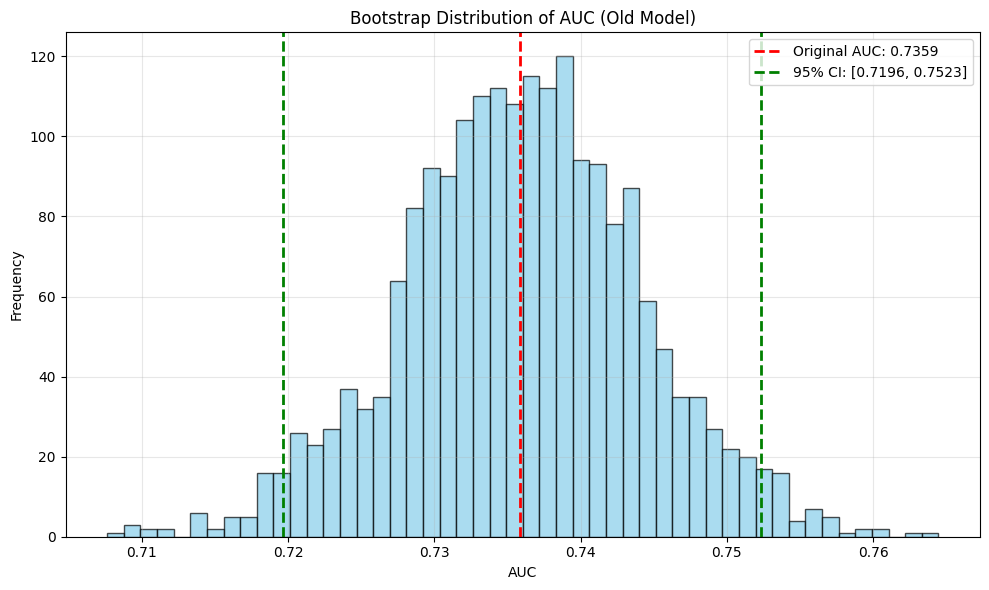

In [20]:
# Visualize the bootstrap distribution of AUC for 'old' model
results_old = results_dict['old']

plt.figure(figsize=(10, 6))
plt.hist(results_old['bootstrap_aucs'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(results_old['original_auc'], color='red', linestyle='--', 
            linewidth=2, label=f'Original AUC: {results_old["original_auc"]:.4f}')
plt.axvline(results_old['ci_lower'], color='green', linestyle='--', 
            linewidth=2, label=f'95% CI: [{results_old["ci_lower"]:.4f}, {results_old["ci_upper"]:.4f}]')
plt.axvline(results_old['ci_upper'], color='green', linestyle='--', linewidth=2)
plt.xlabel('AUC')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of AUC (Old Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

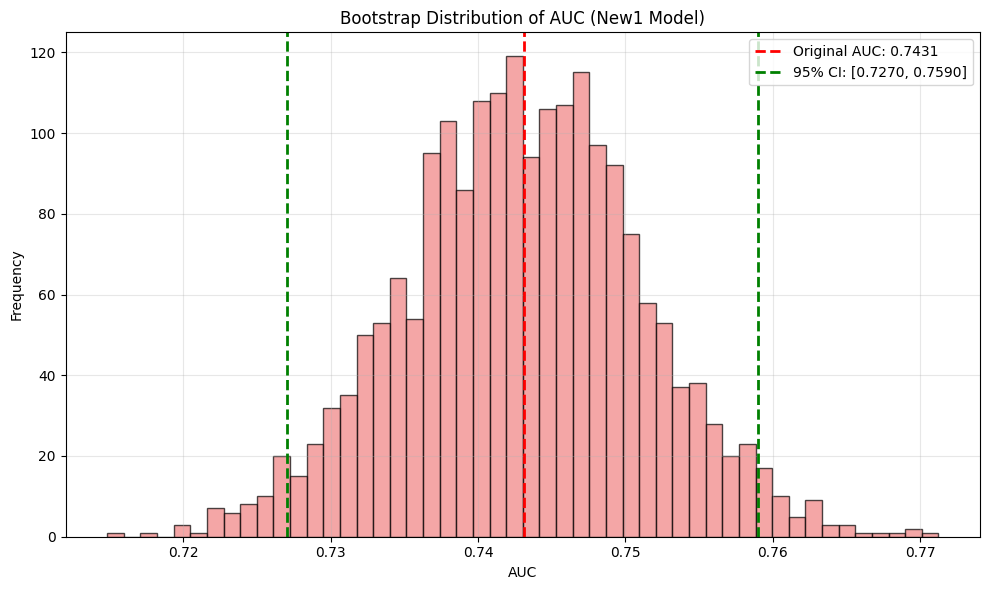

In [21]:
# Visualize the bootstrap distribution of AUC for 'new1' model
results_new1 = results_dict['new1']

plt.figure(figsize=(10, 6))
plt.hist(results_new1['bootstrap_aucs'], bins=50, alpha=0.7, edgecolor='black', color='lightcoral')
plt.axvline(results_new1['original_auc'], color='red', linestyle='--', 
            linewidth=2, label=f'Original AUC: {results_new1["original_auc"]:.4f}')
plt.axvline(results_new1['ci_lower'], color='green', linestyle='--', 
            linewidth=2, label=f'95% CI: [{results_new1["ci_lower"]:.4f}, {results_new1["ci_upper"]:.4f}]')
plt.axvline(results_new1['ci_upper'], color='green', linestyle='--', linewidth=2)
plt.xlabel('AUC')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of AUC (New1 Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

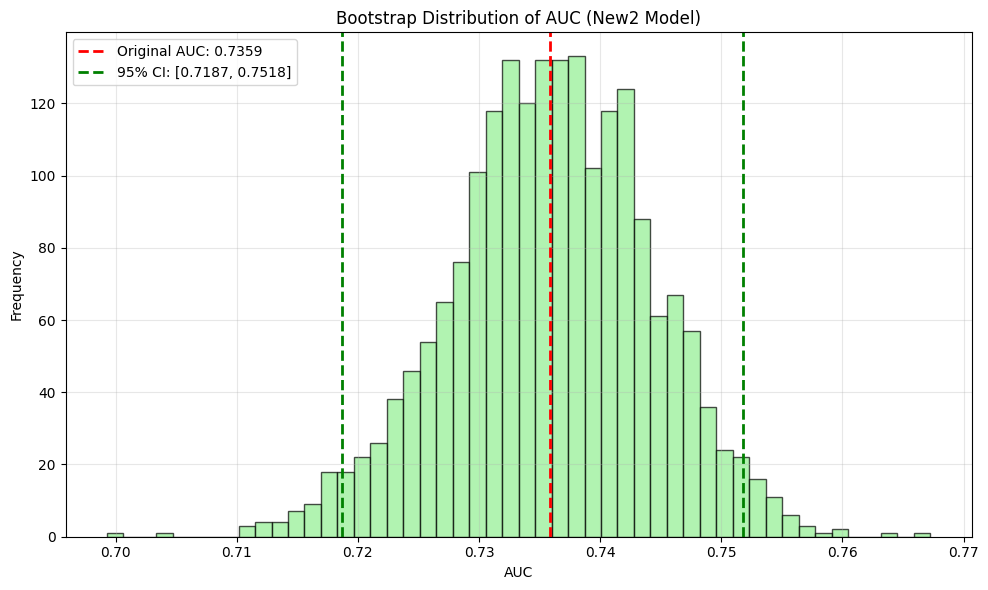

In [22]:
# Visualize the bootstrap distribution of AUC for 'new2' model
results_new2 = results_dict['new2']

plt.figure(figsize=(10, 6))
plt.hist(results_new2['bootstrap_aucs'], bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
plt.axvline(results_new2['original_auc'], color='red', linestyle='--', 
            linewidth=2, label=f'Original AUC: {results_new2["original_auc"]:.4f}')
plt.axvline(results_new2['ci_lower'], color='green', linestyle='--', 
            linewidth=2, label=f'95% CI: [{results_new2["ci_lower"]:.4f}, {results_new2["ci_upper"]:.4f}]')
plt.axvline(results_new2['ci_upper'], color='green', linestyle='--', linewidth=2)
plt.xlabel('AUC')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of AUC (New2 Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

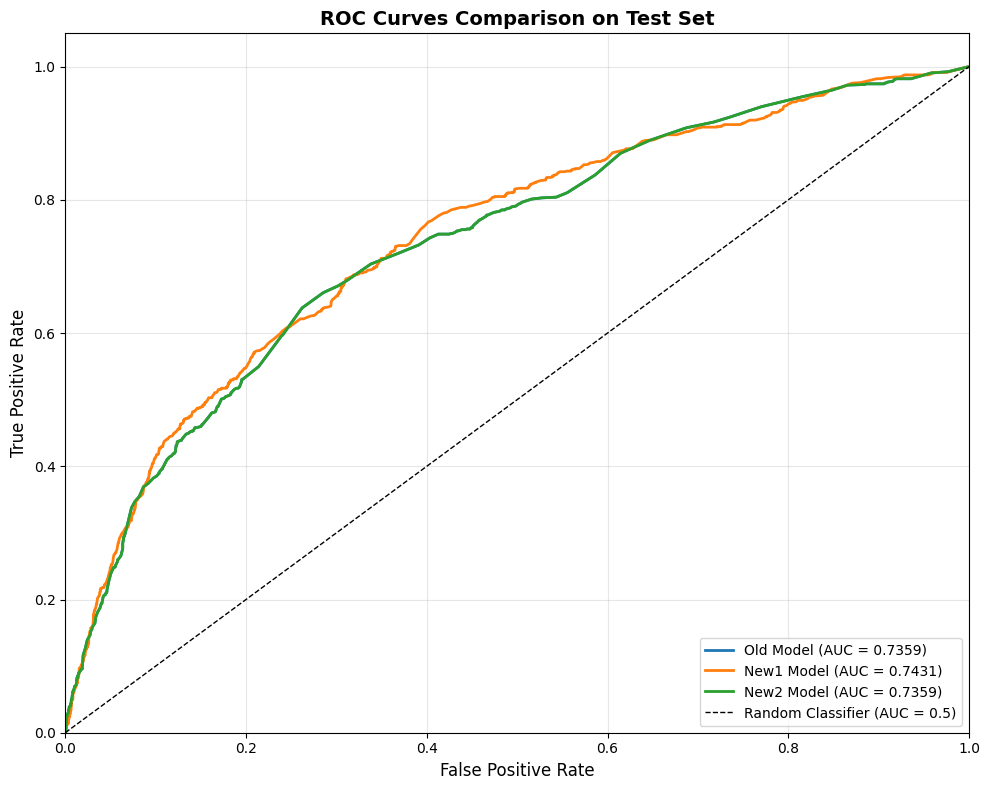

In [23]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for all three models on the test set
plt.figure(figsize=(10, 8))

# Plot for old model
fpr_old, tpr_old, _ = roc_curve(y_preds['y_true'], y_preds['yold'])
roc_auc_old = auc(fpr_old, tpr_old)
plt.plot(fpr_old, tpr_old, linewidth=2, label=f'Old Model (AUC = {roc_auc_old:.4f})')

# Plot for new1 model
fpr_new1, tpr_new1, _ = roc_curve(y_preds['y_true'], y_preds['ynew1'])
roc_auc_new1 = auc(fpr_new1, tpr_new1)
plt.plot(fpr_new1, tpr_new1, linewidth=2, label=f'New1 Model (AUC = {roc_auc_new1:.4f})')

# Plot for new2 model
fpr_new2, tpr_new2, _ = roc_curve(y_preds['y_true'], y_preds['ynew2'])
roc_auc_new2 = auc(fpr_new2, tpr_new2)
plt.plot(fpr_new2, tpr_new2, linewidth=2, label=f'New2 Model (AUC = {roc_auc_new2:.4f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison on Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()


new feature:1st screen

e feature analysis

correlation matrixs

histogram

roc

when positive comes from

interaction term

groupby

improve fasterrisk？